In [8]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import math
from sklearn.utils.extmath import randomized_svd
import warnings

warnings.filterwarnings("ignore")

Image found locally: test_photo.jpg
Size of the original image matrix: (8640, 15360)


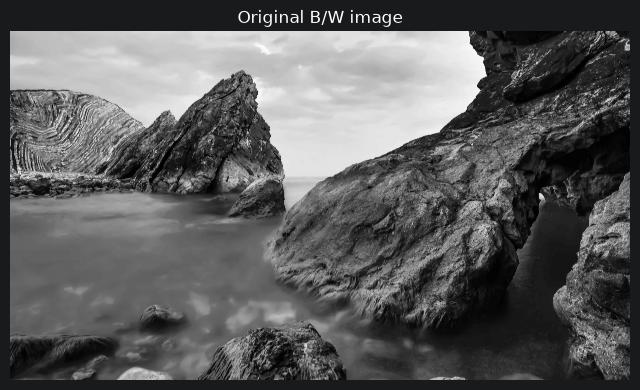

In [9]:
local_path = "test_photo.jpg"

try:
    print(f"Image found locally: {local_path}")
    img = Image.open(local_path)

    img_gray = img.convert('L')

    image_matrix = np.array(img_gray)
    print(f"Size of the original image matrix: {image_matrix.shape}")

    plt.figure(figsize=(8, 6))
    plt.imshow(image_matrix, cmap='gray')
    plt.title("Original B/W image")
    plt.axis('off')
    plt.show()
except Exception as e: print(f"Error loading or processing the image: {e}")

In [10]:
max_k = 100

print(f"Computing SVD (k={max_k}) for B/W image")
U, S, VT = randomized_svd(image_matrix, n_components=max_k, random_state=42)
svd_results = (U, S, VT)
print(f"B/W image (shape {image_matrix.shape}) processed!")

print("SVD for B/W image is complete")

Computing SVD (k=100) for B/W image
B/W image (shape (8640, 15360)) processed!
SVD for B/W image is complete


In [11]:
def reconstruct_image(svd_results, k):
    U, S, VT = svd_results

    reconstructed_img = U[:, :k] @ np.diag(S[:k]) @ VT[:k, :]
    reconstructed_img = np.clip(reconstructed_img, 0, 255).astype(np.uint8)

    return reconstructed_img

In [12]:
def calculate_psnr(original, compressed):
    mse = np.mean((original.astype(float) - compressed.astype(float)) ** 2)
    if mse == 0: return float('inf')
    max_pixel = 255.0
    return 20 * math.log10(max_pixel / math.sqrt(mse))

k_values = [5, 10, 25, 50, 100]
height, width = image_matrix.shape

original_size = height * width

print("=== Experiments with different k values for B/W ===")

for k in k_values:
    reconstructed_img = reconstruct_image(svd_results, k)

    compressed_size = height * k + k + k * width
    compression_ratio = original_size / compressed_size

    psnr = calculate_psnr(image_matrix, reconstructed_img)

    print(f"Number of components: {k}")
    print(f"Original number of values: {original_size:,}")
    print(f"After compression: {compressed_size:,}")
    print(f"Compression ratio: {compression_ratio:.2f}x")
    print(f"PSNR (quality): {psnr:.2f} dB")
    print("-" * 45)

=== Experiments with different k values for B/W ===
Number of components: 5
Original number of values: 132,710,400
After compression: 120,005
Compression ratio: 1105.87x
PSNR (quality): 17.40 dB
---------------------------------------------
Number of components: 10
Original number of values: 132,710,400
After compression: 240,010
Compression ratio: 552.94x
PSNR (quality): 18.59 dB
---------------------------------------------
Number of components: 25
Original number of values: 132,710,400
After compression: 600,025
Compression ratio: 221.17x
PSNR (quality): 20.11 dB
---------------------------------------------
Number of components: 50
Original number of values: 132,710,400
After compression: 1,200,050
Compression ratio: 110.59x
PSNR (quality): 21.27 dB
---------------------------------------------
Number of components: 100
Original number of values: 132,710,400
After compression: 2,400,100
Compression ratio: 55.29x
PSNR (quality): 22.61 dB
---------------------------------------------

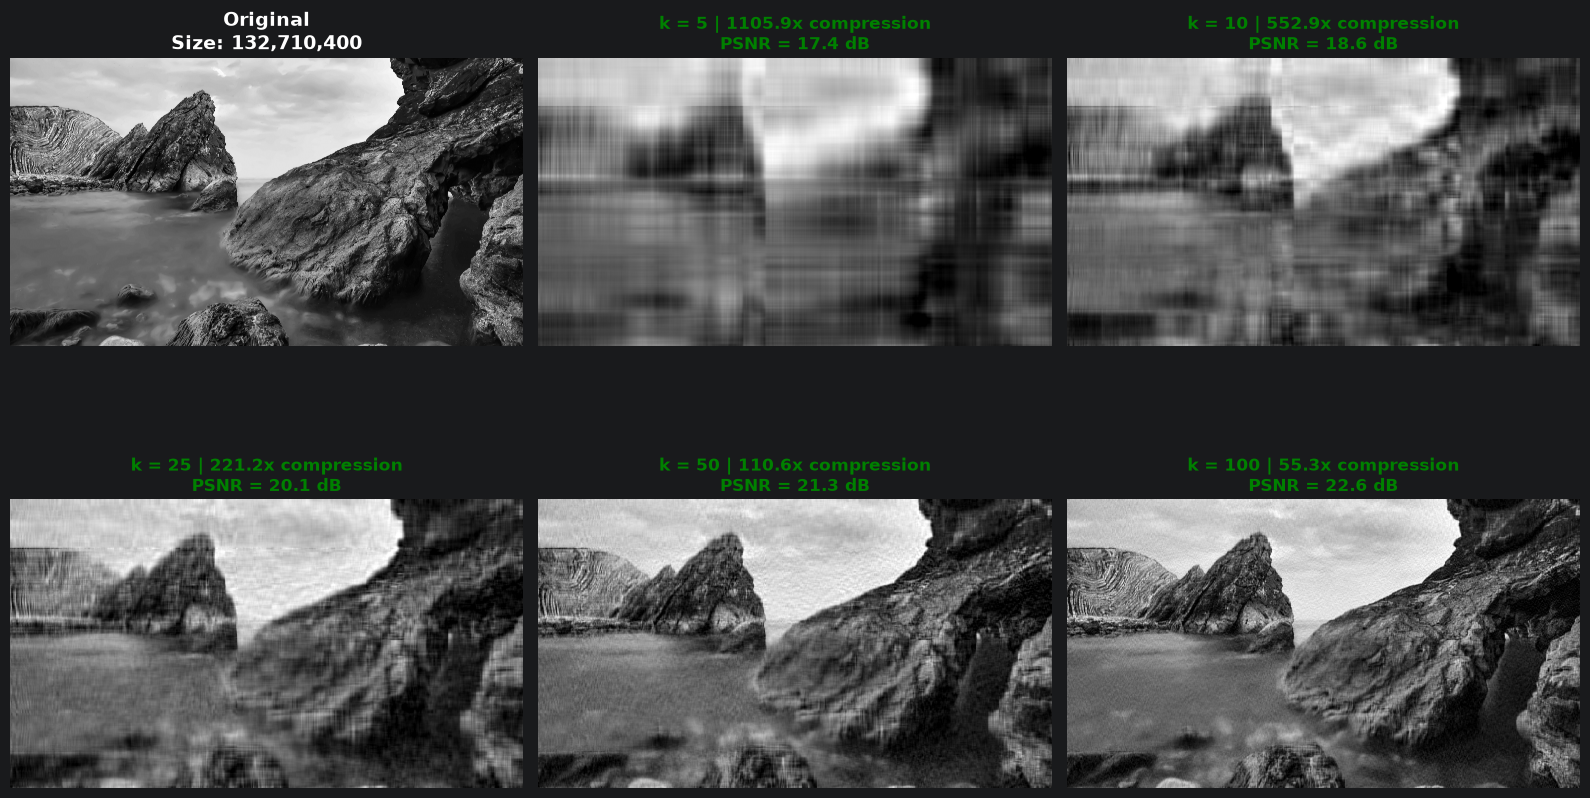

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

axes[0].imshow(image_matrix, cmap='gray')
axes[0].set_title(f"Original\nSize: {original_size:,}", fontsize=14, fontweight='bold')
axes[0].axis('off')

for index, k in enumerate(k_values, start=1):
    reconstructed_img = reconstruct_image(svd_results, k)

    compressed_size = height * k + k + k * width
    compression_ratio = original_size / compressed_size
    psnr = calculate_psnr(image_matrix, reconstructed_img)

    title_color = 'green' if compression_ratio >= 10 else 'red'

    axes[index].imshow(reconstructed_img, cmap='gray')
    axes[index].set_title(f"k = {k} | {compression_ratio:.1f}x compression\nPSNR = {psnr:.1f} dB", fontsize=12, color=title_color, fontweight='bold')
    axes[index].axis('off')

plt.tight_layout()
plt.show()